<a href="https://colab.research.google.com/github/melyhorman/melyhorman.github.io/blob/main/python/Project2_Client_Behavior_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagian Baru

#1 . Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2 . Load File

In [ ]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/FEB26_FSDANEXT_Bellatrix/FINAL CLIENT SEGMENTATION.csv',
    sep=';'
)


In [ ]:
df.head()

,user_id,user_name,total_transactions,total_revenue,engagement_rate_pct,success_rate_pct,final_segment
0,user_3,CV Wisata Indo,24.635,5.207.360,"22,85%","79,57%",High Value Client
1,user_2,PT Dana Nusantara,24.518,5.198.910,"23,05%","79,87%",High Value Client
2,user_1,CV Land Sejahtera,24.496,5.125.530,"23,46%","79,32%",High Value Client
3,user_4,PT Konektivitas Indo,6.230,1.276.070,"22,33%","78,88%",Core Operational Client
4,user_5,PT Karya Sejahtera,6.198,1.310.570,"22,65%","79,27%",Core Operational Client


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns

Index(['user_id', 'user_name', 'total_transactions', 'total_revenue',
       'engagement_rate_pct', 'success_rate_pct', 'final_segment'],
      dtype='object')

#3 . Data type Check

In [ ]:
df.dtypes

,0
user_id,object
user_name,object
total_transactions,float64
total_revenue,object
engagement_rate_pct,object
success_rate_pct,object
final_segment,object


In [ ]:
numeric_cols_thousands_separator = [
    'total_transactions',
    'total_revenue'
]

numeric_cols_percentage = [
    'engagement_rate_pct',
    'success_rate_pct'
]

for col in numeric_cols_thousands_separator:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False) # Remove thousands separator
        .astype(float)
    )

for col in numeric_cols_percentage:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False) # Remove percentage sign
        .str.replace(',', '.', regex=False) # Replace comma decimal with dot decimal
        .astype(float)
    )

In [ ]:
# Sanity Check
df.dtypes

,0
user_id,object
user_name,object
total_transactions,float64
total_revenue,float64
engagement_rate_pct,float64
success_rate_pct,float64
final_segment,object


#4 . Feature Selection

In [ ]:
features = df[[
    'total_transactions',
    'total_revenue',
    'engagement_rate_pct',
    'success_rate_pct'
]]

#5 . Standardization

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

#6 . Kmeans Clustering

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(scaled_features)
df[['user_name', 'final_segment', 'cluster']]

,user_name,final_segment,cluster
0,CV Wisata Indo,High Value Client,2
1,PT Dana Nusantara,High Value Client,2
2,CV Land Sejahtera,High Value Client,2
3,PT Konektivitas Indo,Core Operational Client,3
4,PT Karya Sejahtera,Core Operational Client,3
5,PT Retail Sejahtera,Core Operational Client,0
6,PT Belajar Nusantara,Core Operational Client,0
7,PT Logistik Mandiri,Core Operational Client,0
8,PT Estate Sejahtera,Retention Risk,1
9,CV Jalan Mandiri,Retention Risk,1


Rule-based segmentation was validated using KMeans clustering to identify natural behavioral grouping patterns among enterprise clients.

#7 . Visualization

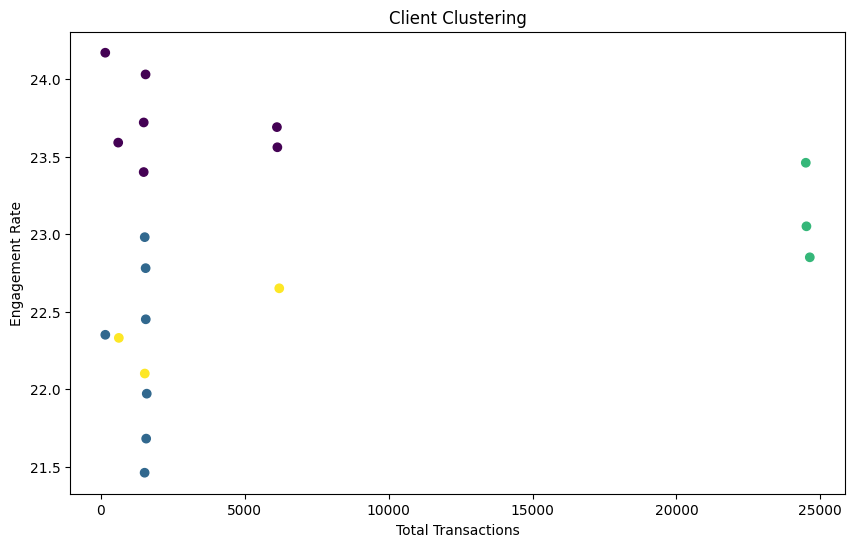

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['total_transactions'],
    df['engagement_rate_pct'],
    c=df['cluster']
)

plt.xlabel('Total Transactions')
plt.ylabel('Engagement Rate')
plt.title('Client Clustering')

plt.show()

Behavioral clusters remain highly aligned with rule-based segmentation outputs, indicating stable user activity patterns across enterprise clients.
Behavioral clustering validation confirms similar operational patterns across high-value, retention-risk, and low-activity client groups.

In [ ]:
#PCA VISUALIZATION
from sklearn.decomposition import PCA

# Reduce dimension
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_features,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = df['cluster']
pca_df['user_name'] = df['user_name']

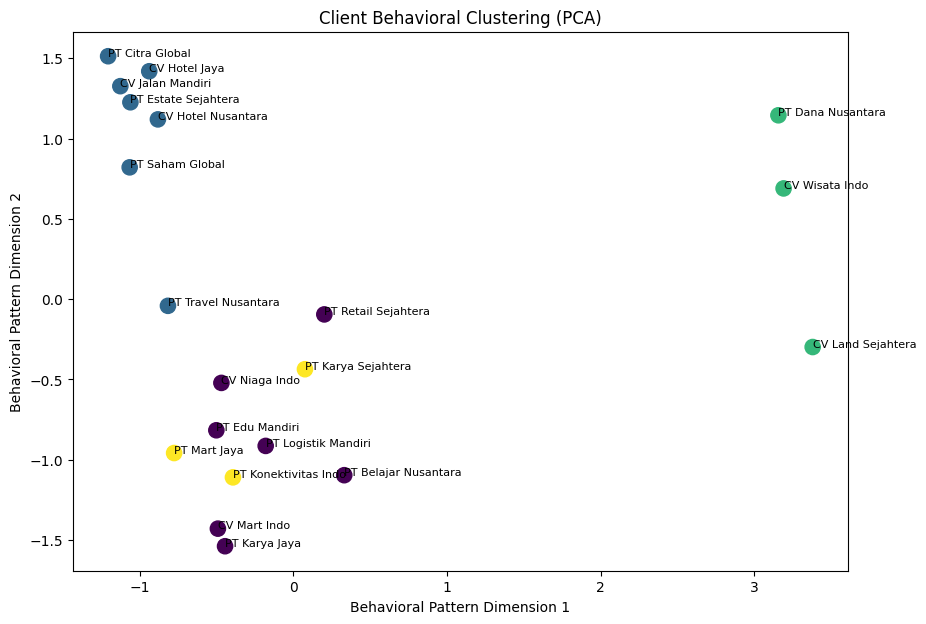

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
    s=120
)

for i, txt in enumerate(pca_df['user_name']):
    plt.annotate(
        txt,
        (pca_df['PC1'][i], pca_df['PC2'][i]),
        fontsize=8
    )

plt.title('Client Behavioral Clustering (PCA)')

plt.xlabel('Behavioral Pattern Dimension 1')
plt.ylabel('Behavioral Pattern Dimension 2')

plt.show()

#8 . Intrepretation Cluster

In [ ]:
df.groupby('cluster')[[
    'total_transactions',
    'total_revenue',
    'engagement_rate_pct',
    'success_rate_pct'
]].mean()

,total_transactions,total_revenue,engagement_rate_pct,success_rate_pct
cluster,,,,
0,2504.000000,7.398386e+05,23.737143,79.502857
1,1353.428571,3.322014e+05,22.238571,79.930000
2,24549.666667,5.177267e+06,23.120000,79.586667
3,2782.000000,9.701133e+05,22.360000,79.013333
